In [4]:
!pip install yfinance

  Using cached yfinance-1.1.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached platformdirs-4.5.1-py3-none-any.whl.metadata (12 kB)
  Using cached frozendict-2.4.7-cp310-cp310-win_amd64.whl.metadata (24 kB)
  Using cached peewee-3.19.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\hp\\AppData\\Local\\Temp\\pip-unpack-va9i62d3\\curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata'
Consider using the `--user` option or check the permissions.



In [6]:
import sys
print(sys.executable)

C:\Users\hp\AppData\Local\Programs\Python\Python312\python.exe


In [1]:
import yfinance as yf
print("yfinance imported successfully!")
!pip install --upgrade yfinance

yfinance imported successfully!
  Using cached yfinance-1.1.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached platformdirs-4.5.1-py3-none-any.whl.metadata (12 kB)
  Using cached frozendict-2.4.7-cp310-cp310-win_amd64.whl.metadata (24 kB)
  Using cached peewee-3.19.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.4-cp310-cp310-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


[*********************100%***********************]  1 of 1 completed
C:\Users\hp\AppData\Local\Temp\ipykernel_15292\2093443837.py:11: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df=df.drop(['Date'],axis=1)


Price       Close       High        Low       Open     Volume
Ticker       AAPL       AAPL       AAPL       AAPL       AAPL
0       24.237555  24.705324  23.798604  24.694239  212818400
1       23.554743  24.086803  23.368523  24.006994  257142000
2       23.556959  23.816338  23.195601  23.619033  263188400
3       23.887276  23.987036  23.654499  23.765345  160423600
4       24.805084  24.862725  24.097887  24.215385  237458000


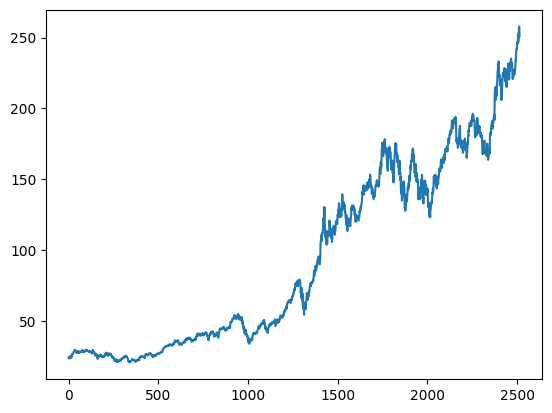

In [2]:
#application is based on close column
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

start="2015-01-01"
end="2024-12-31"
df = yf.download('AAPL', start=start, end=end)
df=df.reset_index()
df=df.drop(['Date'],axis=1)
print(df.head())
plt.plot(df.Close)

In [3]:
ma100=df.Close.rolling(100).mean()
ma100

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,228.189310
2511,228.575917
2512,229.075872
2513,229.561944


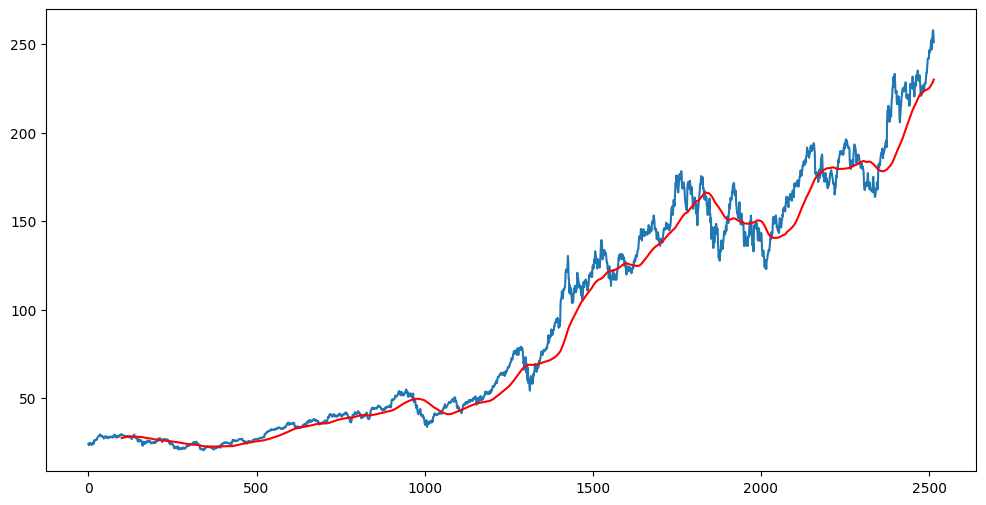

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [5]:
ma200=df.Close.rolling(200).mean()
ma200

Ticker,AAPL
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2510,210.034463
2511,210.462889
2512,210.893017
2513,211.316486


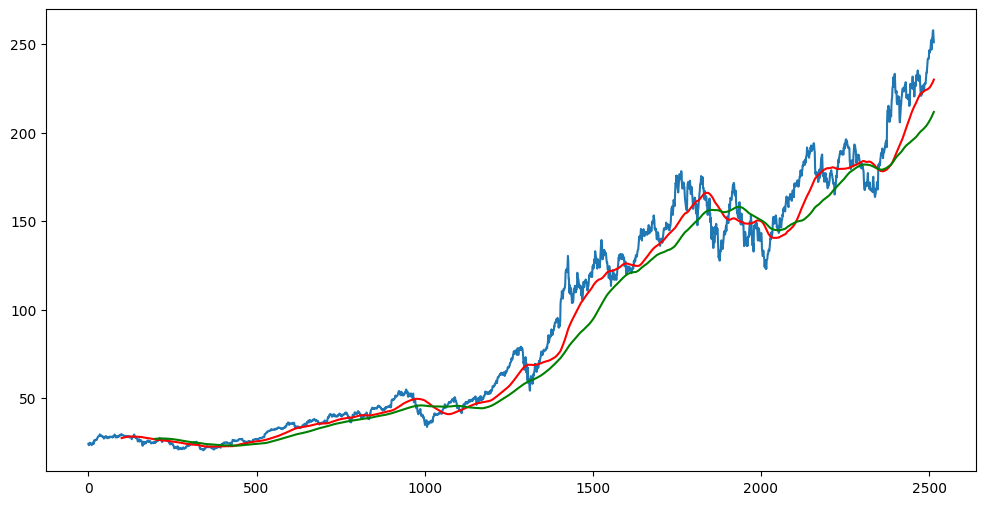

In [6]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'g')

In [7]:
df.shape

(2515, 5)

In [8]:
#spliting data into trainig and testing
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])#70%
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])#30%
print(data_training.shape)
print(data_testing.shape)

(1760, 1)
(755, 1)


In [9]:
data_training.head()

Ticker,AAPL
0,24.237555
1,23.554743
2,23.556959
3,23.887276
4,24.805084


In [10]:
data_testing.head()

Ticker,AAPL
1760,175.694351
1761,174.538620
1762,173.921539
1763,178.270340
1764,176.007767


In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.02328845],
       [0.01891204],
       [0.01892624],
       ...,
       [0.9745753 ],
       [1.        ],
       [0.99347118]])

In [12]:
x_train=[]
y_train=[]
for i in range(100,data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])
x_train,y_train=np.array(x_train),np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
print("x_train shape:", x_train.shape)  # Should be (samples, time_steps, 1)

x_train shape: (1660, 100, 1)


In [13]:
!pip install keras

  Using cached keras-3.12.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached pygments-2.19.2-py3-none-any.whl.metadata (2.5 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached keras-3.12.0-py3-none-any.whl (1.5 MB)
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
  

In [14]:
!pip install tensorflow

  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:

In [15]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [16]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

print("Keras imported successfully!")

Keras imported successfully!


In [17]:
#ml model
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

model = Sequential()
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1))
print("x_train shape:", x_train.shape)  # Should be (samples, time_steps, 1)
model.summary()

C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


x_train shape: (1660, 100, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - loss: 0.0247
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - loss: 0.0053
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step - loss: 0.0051
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step - loss: 0.0041
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - loss: 0.0056
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - loss: 0.0047
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - loss: 0.0042
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - loss: 0.0041
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - loss: 0.0039
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - loss: 0.0038
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 205ms/step - loss: 0.0034
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - loss: 0.0031
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - loss: 0.0028
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - loss: 0.0031
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 

In [19]:
model.save('keras_model.h5',save_format="h5")

In [20]:
past_100_days=data_training.tail(100)
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df.head()

Ticker,AAPL
0,142.928726
1,142.879837
2,142.400604
3,142.654861
4,145.618286


In [21]:
input_data=scaler.fit_transform(final_df)
input_data.shape

(855, 1)

In [22]:
x_test=[]
y_test=[]
for i in range(100,input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])
x_test,y_test=np.array(x_test),np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
print("x_test shape:", x_test.shape)  # Should be (samples, time_steps, 1)
print("y_test shape:", y_test.shape)  # Should be (samples,)

x_test shape: (755, 100, 1)
y_test shape: (755,)


In [23]:
y_predicted=model.predict(x_test)
print(y_predicted.shape)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step
(755, 1)


In [24]:
scaler.scale_

array([0.00742435])

In [26]:
scaler_factor=1/0.00739093
y_predicted=y_predicted*scaler_factor
y_test=y_test*scaler_factor

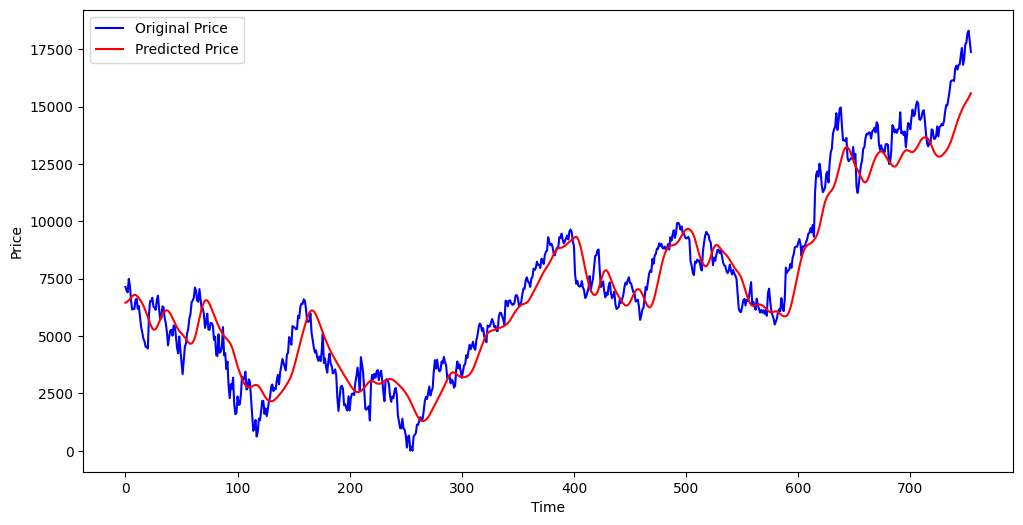

In [27]:
plt.figure(figsize=(12,6))
plt.plot(y_test,'b',label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()